<a href="https://colab.research.google.com/github/naylaviona/Machine-Learning/blob/main/MachineLearning_Kelompok_NaiveBayes_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import plot_tree

In [23]:
# LOAD DATASET
url = "https://raw.githubusercontent.com/naylaviona/Machine-Learning/main/mahasiswa_lulus.csv"

# Membaca dataset
df = pd.read_csv(url)

print("=== CHECK MISSING VALUES SEBELUM IMPUTASI ===")
print(df.isnull().sum())
print("-" * 50)

=== CHECK MISSING VALUES SEBELUM IMPUTASI ===
IPK                  15
Kehadiran            15
Jam_Belajar           0
Organisasi            0
Penghasilan_Ortu      0
Jenis_Kelamin         0
Status_Beasiswa       0
Lulus_Tepat_Waktu     0
dtype: int64
--------------------------------------------------


In [ ]:
# HANDLE MISSING VALUE
# Mengisi missing values pada kolom numerik dengan nilai median
df['IPK'] = df['IPK'].fillna(df['IPK'].median())
df['Kehadiran'] = df['Kehadiran'].fillna(df['Kehadiran'].median())

In [ ]:
# ENCODING FITUR KATEGORIKAL & TARGET
# Hanya fitur kategorikal yang di-encode dengan LabelEncoder
categorical_cols = ['Organisasi', 'Penghasilan_Ortu', 'Jenis_Kelamin', 'Status_Beasiswa']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Target dimapping manual secara eksplisit:
# 1 = Tepat Waktu (Positif)
# 0 = Tidak Tepat Waktu (Negatif)
df['Lulus_Tepat_Waktu'] = df['Lulus_Tepat_Waktu'].map({
    'Tidak Tepat Waktu': 0,
    'Tepat Waktu': 1
})

In [ ]:
# MEMISAHKAN FITUR (X) DAN TARGET (Y)
X = df.drop(columns=['Lulus_Tepat_Waktu'])
y = df['Lulus_Tepat_Waktu']

In [ ]:
# TRAIN-TEST SPLIT (80% TRAIN, 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== HASIL PREPROCESSING & SPLITTING ===")
print(f"Jumlah Data Train (X_train) : {X_train.shape[0]} sampel (80%)")
print(f"Jumlah Data Test  (X_test)  : {X_test.shape[0]} sampel (20%)")
print("\nPreview 5 data teratas X_train:")
print(X_train.head())

=== HASIL PREPROCESSING & SPLITTING ===
Jumlah Data Train (X_train) : 400 sampel (80%)
Jumlah Data Test  (X_test)  : 100 sampel (20%)

Preview 5 data teratas X_train:
      IPK  Kehadiran  Jam_Belajar  Organisasi  Penghasilan_Ortu  \
484  3.17       97.0           15           0                 0   
333  2.23       51.0           19           0                 1   
338  2.95       66.0            7           1                 1   
36   2.61       62.0            8           1                 1   
102  2.63       99.0           19           1                 0   

     Jenis_Kelamin  Status_Beasiswa  
484              0                0  
333              1                0  
338              0                0  
36               1                0  
102              0                0  


In [ ]:
# MODEL 1: Decision Tree Classifier (max_depth=3)

# 1. Inisialisasi Model
# max_depth=3 membatasi kedalaman pohon keputusan maksimal 3 tingkat untuk menghindari overfitting
clf_dt3 = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Melatih Model (Fit)
# Menggunakan X_train dan y_train yang telah diproses oleh Anggota 1
clf_dt3.fit(X_train, y_train)

# 3. Prediksi Data Test
# Menguji performa model terhadap data X_test
y_pred_dt3 = clf_dt3.predict(X_test)

# 4. Tampilkan Sampel Hasil Prediksi
print("=== MODEL 1: DECISION TREE (max_depth=3) ===")
print("Status: Berhasil dilatih dan diprediksi.")
print(f"5 Prediksi Pertama: {y_pred_dt3[:5]}\n")

=== MODEL 1: DECISION TREE (max_depth=3) ===
Status: Berhasil dilatih dan diprediksi.
5 Prediksi Pertama: [0 1 1 0 1]



In [ ]:
# MODEL 2: Decision Tree Classifier (max_depth=None / Tanpa Batasan Kedalaman)

# 1. Inisialisasi Model
# max_depth=None membiarkan pohon tumbuh maksimal sampai seluruh leaf murni (rawan overfitting)
clf_dt_full = DecisionTreeClassifier(max_depth=None, random_state=42)

# 2. Melatih Model (Fit)
# Menggunakan X_train dan y_train yang telah diproses oleh Anggota 1
clf_dt_full.fit(X_train, y_train)

# 3. Prediksi Data Test
# Menguji performa model terhadap data X_test
y_pred_dt_full = clf_dt_full.predict(X_test)

# 4. Tampilkan Sampel Hasil Prediksi
print("=== MODEL 2: DECISION TREE (FULL DEPTH) ===")
print("Status: Berhasil dilatih dan diprediksi.")
print(f"5 Prediksi Pertama: {y_pred_dt_full[:5]}\n")

=== MODEL 2: DECISION TREE (FULL DEPTH) ===
Status: Berhasil dilatih dan diprediksi.
5 Prediksi Pertama: [0 1 1 0 1]



In [ ]:
# MODEL 3: Gaussian Naive Bayes Classifier

# 1. Inisialisasi Model
# GaussianNB cocok untuk fitur numerik yang diasumsikan berdistribusi normal
clf_gnb = GaussianNB()

# 2. Melatih Model (Fit)
# Menggunakan X_train dan y_train yang telah diproses oleh Anggota 1
clf_gnb.fit(X_train, y_train)

# 3. Prediksi Data Test
# Menguji performa model terhadap data X_test
y_pred_gnb = clf_gnb.predict(X_test)

# 4. Tampilkan Sampel Hasil Prediksi
print("=== MODEL 3: GAUSSIAN NAIVE BAYES ===")
print("Status: Berhasil dilatih dan diprediksi.")
print(f"5 Prediksi Pertama: {y_pred_gnb[:5]}\n")

=== MODEL 3: GAUSSIAN NAIVE BAYES ===
Status: Berhasil dilatih dan diprediksi.
5 Prediksi Pertama: [0 1 0 0 1]



In [ ]:
# EVALUASI PERFORMA MODEL & CONFUSION MATRIX
# Impor Library Evaluasi

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt
import pandas as pd

print("Status: Library evaluasi berhasil diimpor.")

Status: Library evaluasi berhasil diimpor.


In [ ]:
# KUMPULKAN HASIL PREDIKSI DARI SEL PEMODELAN

models_preds = {
    'Decision Tree (max_depth=3)': y_pred_dt3,
    'Decision Tree (Full Depth)': y_pred_dt_full,
    'Gaussian Naive Bayes': y_pred_gnb
}

print("Status: Seluruh hasil prediksi berhasil dikumpulkan.")

Status: Seluruh hasil prediksi berhasil dikumpulkan.


In [ ]:
# TABEL 4 METRIK FOKUS KELULUSAN TEPAT WAKTU (KELAS 1)

results_pos1 = []

for name, y_pred in models_preds.items():
    results_pos1.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision (Tepat)': round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Recall (Tepat)': round(recall_score(y_test, y_pred, pos_label=1), 4),
        'F1-Score (Tepat)': round(f1_score(y_test, y_pred, pos_label=1), 4)
    })

df_evaluasi_pos1 = pd.DataFrame(results_pos1)
print("=== TABEL METRIK EVALUASI KELAS POSITIF (TEPAT WAKTU = 1) ===")
print(df_evaluasi_pos1.to_string(index=False))

=== TABEL METRIK EVALUASI KELAS POSITIF (TEPAT WAKTU = 1) ===
                      Model  Accuracy  Precision (Tepat)  Recall (Tepat)  F1-Score (Tepat)
Decision Tree (max_depth=3)      0.87             0.7857          0.8919            0.8354
 Decision Tree (Full Depth)      0.83             0.7381          0.8378            0.7848
       Gaussian Naive Bayes      0.91             0.8500          0.9189            0.8831


In [ ]:
# EVALUASI MENYELURUH UNTUK KEDUA KATEGORI
# (0 = Tidak Tepat Waktu, 1 = Tepat Waktu)

target_names = ['Tidak Tepat Waktu (0)', 'Tepat Waktu (1)']

print("=== CLASSIFICATION REPORT LENGKAP KEDUA KATEGORI ===")
for name, y_pred in models_preds.items():
    print(f"\n==================== {name} ====================")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

=== CLASSIFICATION REPORT LENGKAP KEDUA KATEGORI ===

==================== Decision Tree (max_depth=3) ====================
                       precision    recall  f1-score   support

Tidak Tepat Waktu (0)     0.9310    0.8571    0.8926        63
      Tepat Waktu (1)     0.7857    0.8919    0.8354        37

             accuracy                         0.8700       100
            macro avg     0.8584    0.8745    0.8640       100
         weighted avg     0.8773    0.8700    0.8714       100


==================== Decision Tree (Full Depth) ====================
                       precision    recall  f1-score   support

Tidak Tepat Waktu (0)     0.8966    0.8254    0.8595        63
      Tepat Waktu (1)     0.7381    0.8378    0.7848        37

             accuracy                         0.8300       100
            macro avg     0.8173    0.8316    0.8222       100
         weighted avg     0.8379    0.8300    0.8319       100


==================== Gaussian Naive Bayes =

In [ ]:
# RINCIAN ANGKA CONFUSION MATRIX SETIAP MODEL

print("=== RINCIAN ANGKA CONFUSION MATRIX ===")

for name, y_pred in models_preds.items():
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- Model: {name} ---")
    print(f"True Negative  (Benar Tidak Tepat)  : {cm[0, 0]}")
    print(f"False Positive (Salah Tebak Tepat)  : {cm[0, 1]}")
    print(f"False Negative (Salah Tebak Tidak)  : {cm[1, 0]}")
    print(f"True Positive  (Benar Tepat Waktu)  : {cm[1, 1]}")

=== RINCIAN ANGKA CONFUSION MATRIX ===

--- Model: Decision Tree (max_depth=3) ---
True Negative  (Benar Tidak Tepat)  : 54
False Positive (Salah Tebak Tepat)  : 9
False Negative (Salah Tebak Tidak)  : 4
True Positive  (Benar Tepat Waktu)  : 33

--- Model: Decision Tree (Full Depth) ---
True Negative  (Benar Tidak Tepat)  : 52
False Positive (Salah Tebak Tepat)  : 11
False Negative (Salah Tebak Tidak)  : 6
True Positive  (Benar Tepat Waktu)  : 31

--- Model: Gaussian Naive Bayes ---
True Negative  (Benar Tidak Tepat)  : 57
False Positive (Salah Tebak Tepat)  : 6
False Negative (Salah Tebak Tidak)  : 3
True Positive  (Benar Tepat Waktu)  : 34


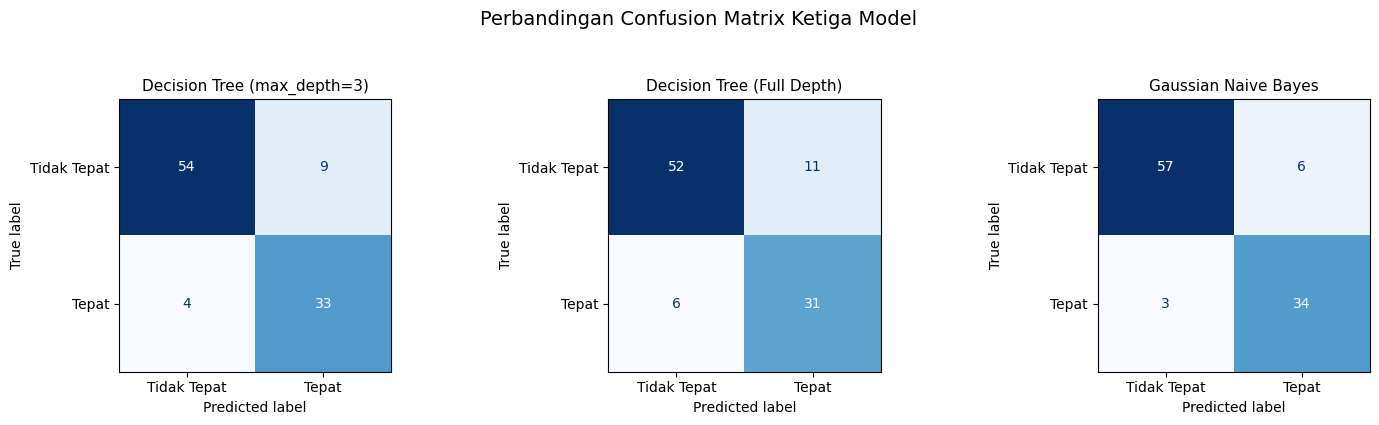

In [ ]:
# VISUALISASI PLOT CONFUSION MATRIX BERDAMPINGAN

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels_target = ['Tidak Tepat', 'Tepat']

for idx, (name, y_pred) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_target
    )
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontsize=11)

plt.suptitle("Perbandingan Confusion Matrix Ketiga Model", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

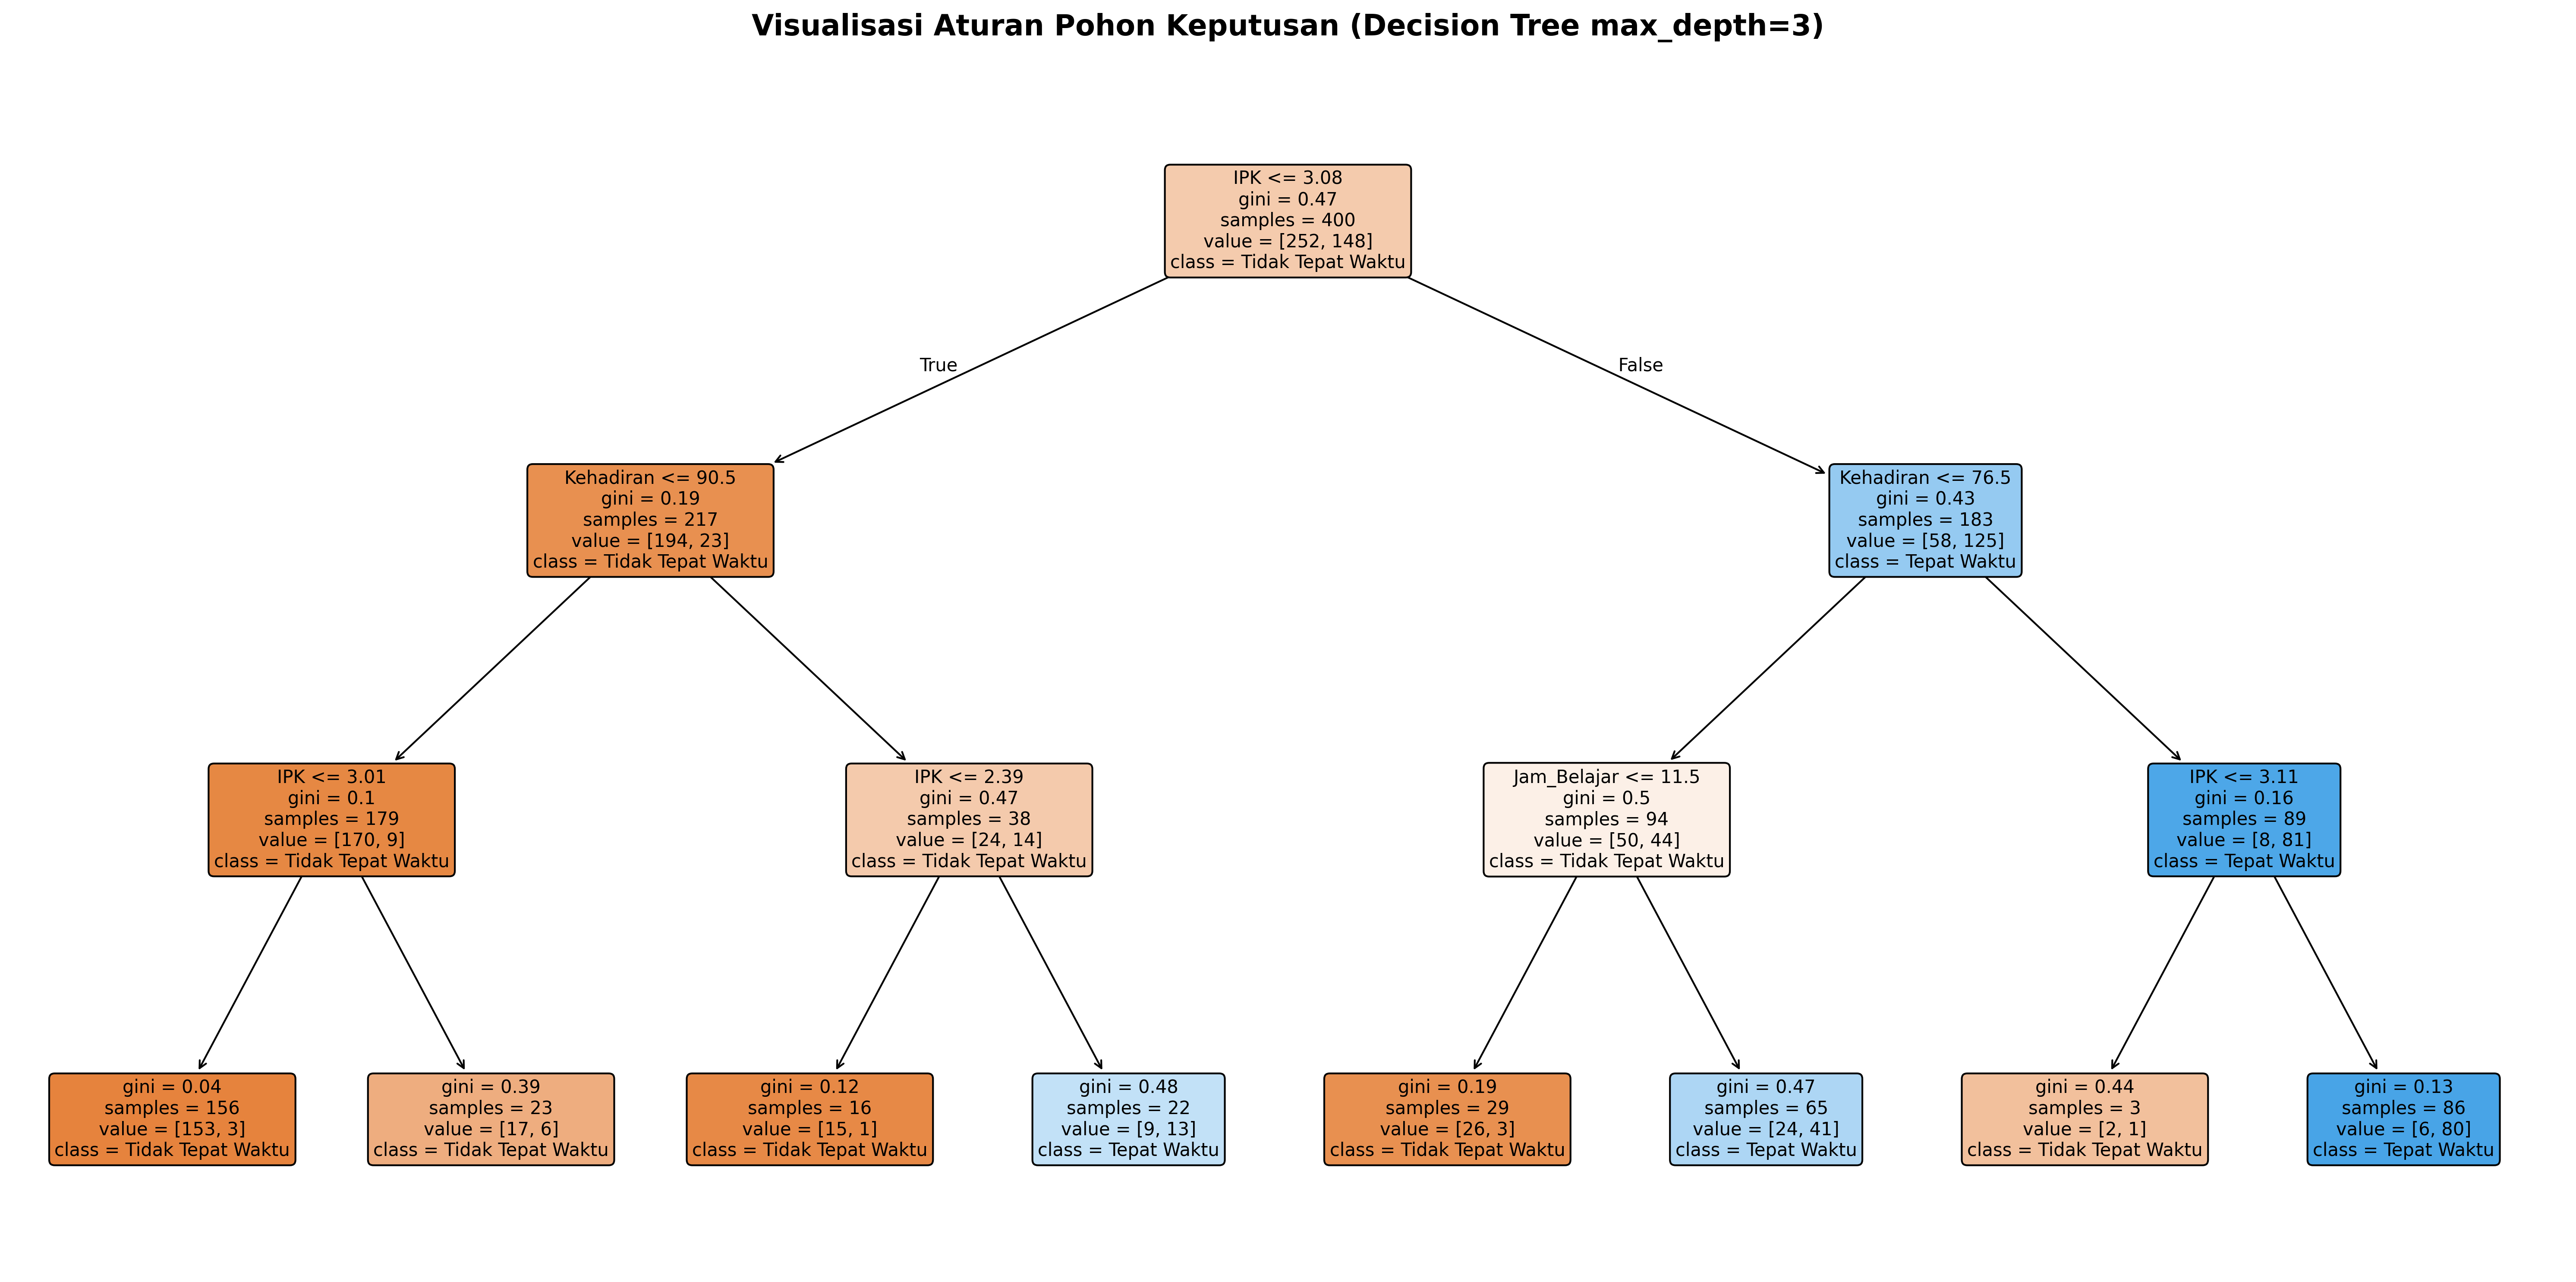

In [ ]:
# 1. Menyiapkan kanvas gambar dengan resolusi tinggi
fig_tree, ax_tree = plt.subplots(figsize=(20, 10), dpi=300)

# 2. Menggambar pohon keputusan dari model clf_dt3
plot_tree(
    clf_dt3,
    feature_names=X.columns.tolist(),
    class_names=['Tidak Tepat Waktu', 'Tepat Waktu'],
    filled=True,
    rounded=True,
    precision=2,
    fontsize=10,
    ax=ax_tree
)

# 3. Menambahkan judul grafik
plt.title(
    "Visualisasi Aturan Pohon Keputusan (Decision Tree max_depth=3)",
    fontsize=16,
    pad=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

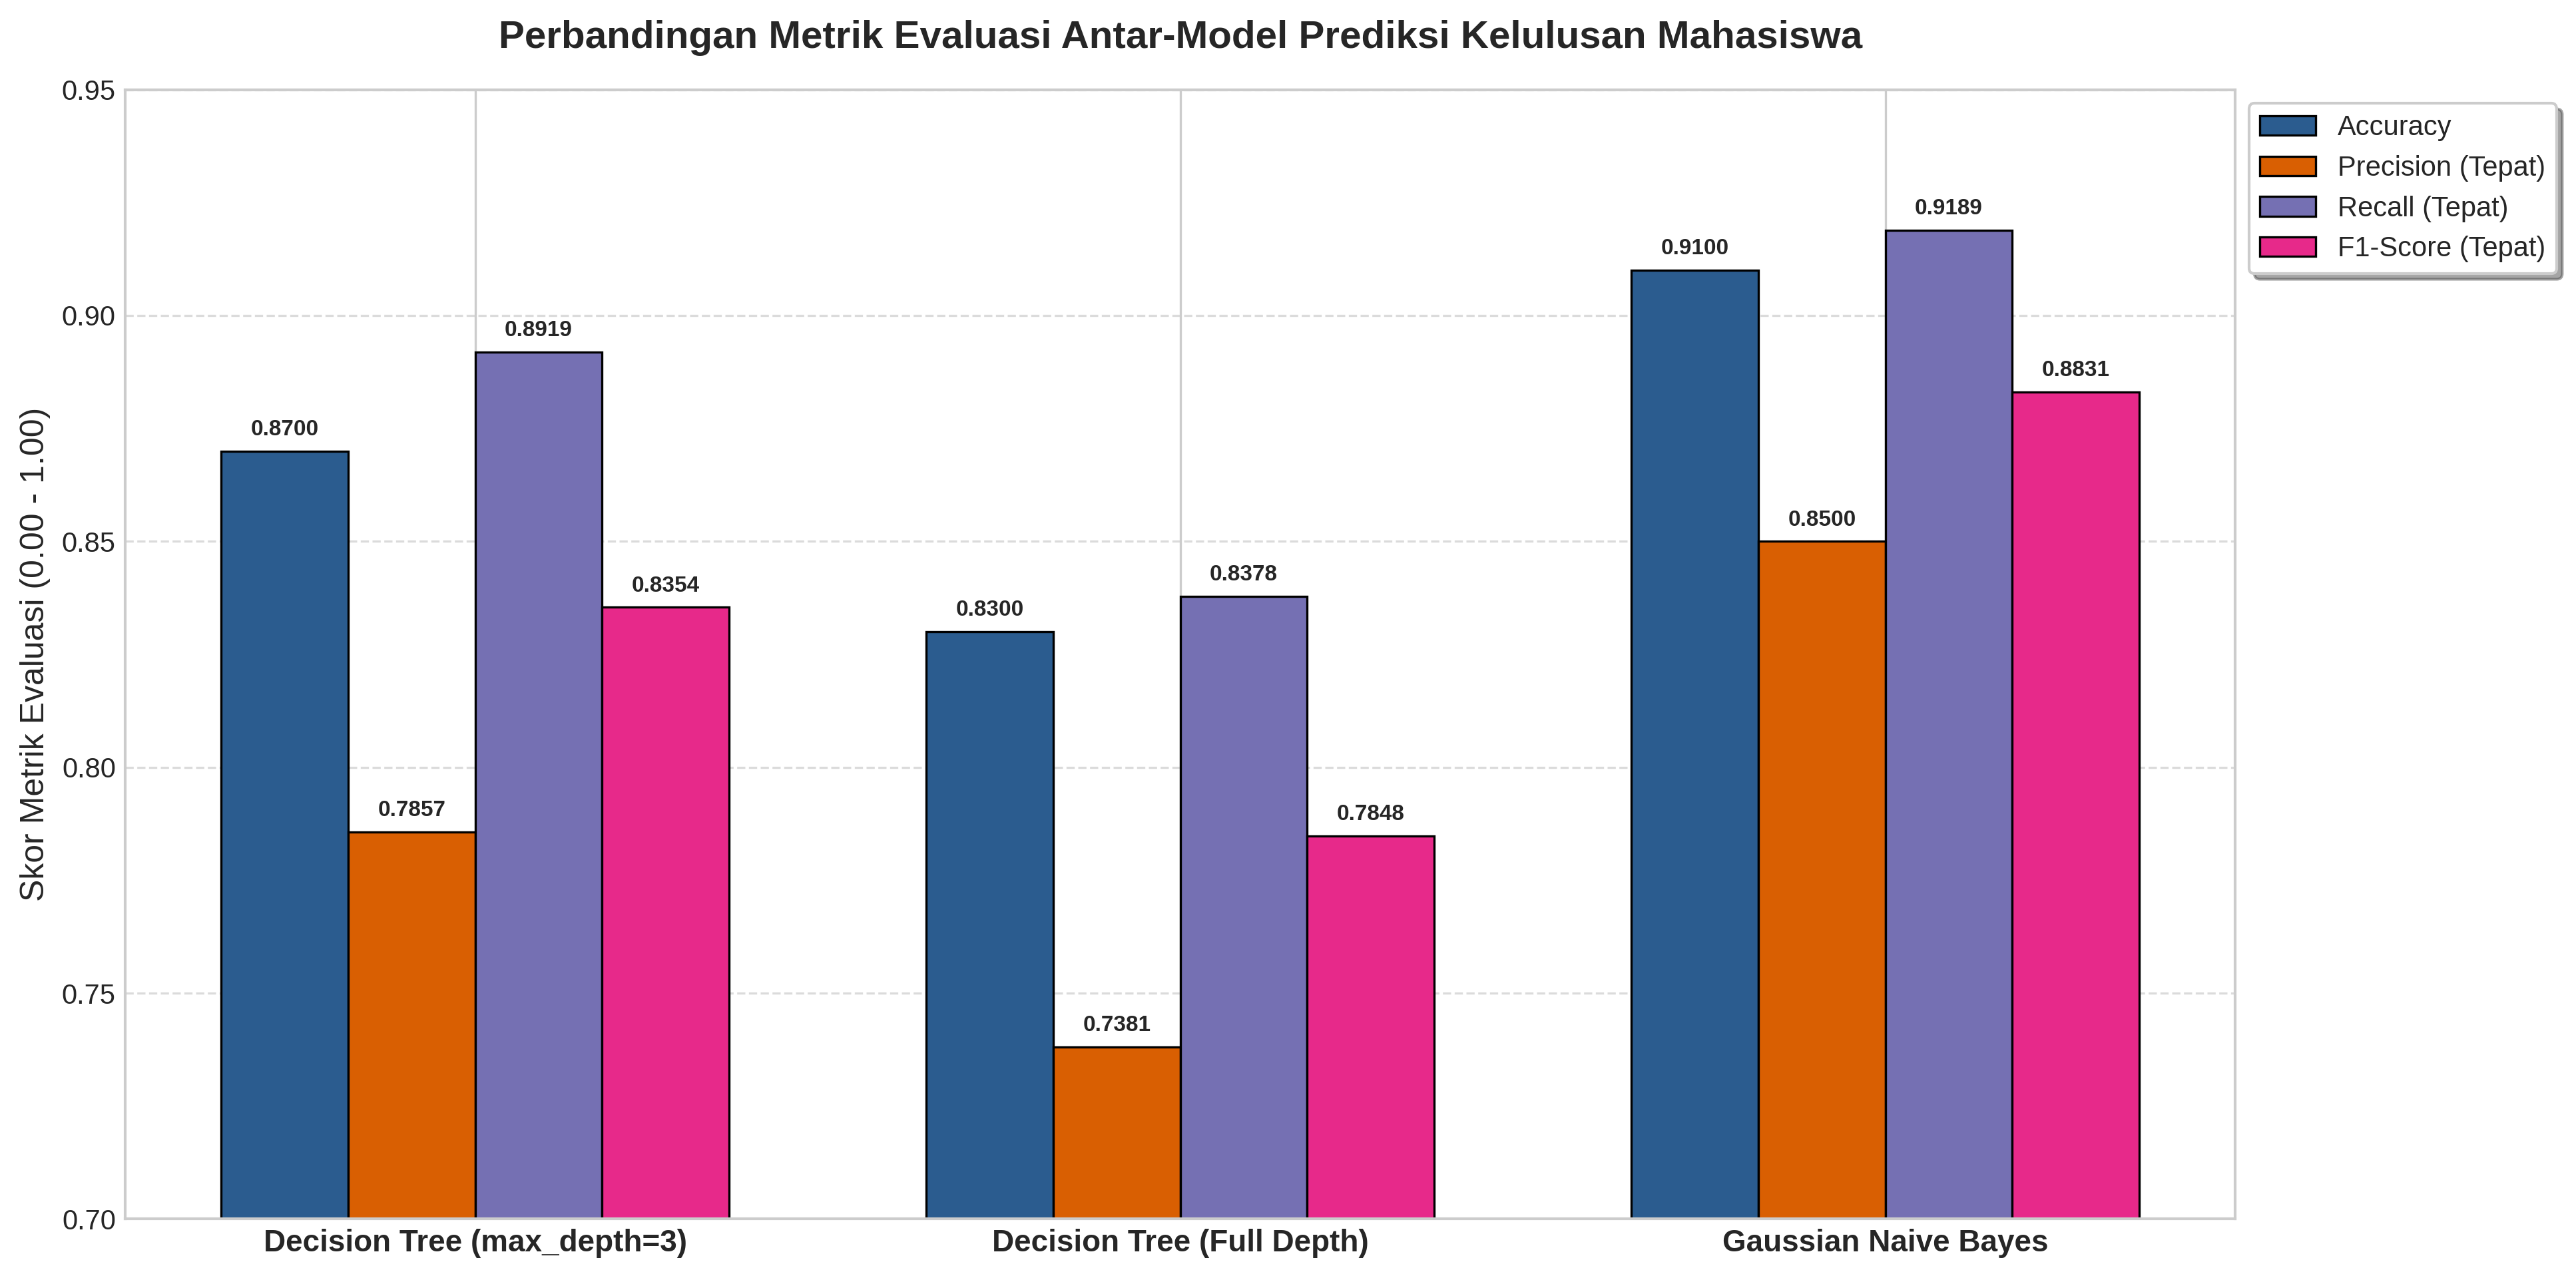

In [ ]:
# SET GAYA VISUALISASI
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Mengambil data metrik dari DataFrame evaluasi sebelumnya
models = df_evaluasi_pos1['Model'].tolist()
metrics = ['Accuracy', 'Precision (Tepat)', 'Recall (Tepat)', 'F1-Score (Tepat)']
values = df_evaluasi_pos1[metrics].values

# 2. Mengatur posisi sumbu X untuk tiap kelompok batang
x = np.arange(len(models))
width = 0.18

fig_bar, ax_bar = plt.subplots(figsize=(13, 6.5), dpi=300)
colors = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a']

# 3. Plot tiap kelompok metrik evaluasi
for i, metric_name in enumerate(metrics):
    offset = width * i - (width * 1.5)
    rects = ax_bar.bar(
        x + offset,
        values[:, i],
        width,
        label=metric_name,
        color=colors[i],
        edgecolor='black',
        linewidth=0.8
    )

    # Menambahkan angka persis di atas setiap batang
    for rect in rects:
        height = rect.get_height()
        ax_bar.annotate(
            f'{height:.4f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

# 4. Pengaturan label dan estetika grafik
ax_bar.set_ylabel('Skor Metrik Evaluasi (0.00 - 1.00)', fontsize=12)
ax_bar.set_title(
    'Perbandingan Metrik Evaluasi Antar-Model Prediksi Kelulusan Mahasiswa',
    fontsize=14,
    pad=15,
    fontweight='bold'
)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(models, fontsize=11, fontweight='bold')
ax_bar.set_ylim(0.70, 0.95)
ax_bar.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True, fontsize=10)
ax_bar.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ANALISIS ERROR (MODEL NAIVE BAYES)

# 1. Gabungkan data X_test, Nilai Aktual (y_test), dan Nilai Prediksi (y_pred)
df_error = X_test.copy()
df_error["Aktual"] = y_test
df_error["Prediksi"] = y_pred_gnb

# Decode kolom kategorikal agar mudah dibaca pada analisis
for col in categorical_cols:
  df_error[col] = label_encoders[col].inverse_transform(df_error[col])

# Mapping label target kembali ke teks
map_target = {0: "Tidak Tepat Waktu", 1: "Tepat Waktu"}
df_error["Aktual"] = df_error["Aktual"].map(map_target)
df_error["Prediksi"] = df_error["Prediksi"].map(map_target)

# 2. Filter hanya data yang salah prediksi (Aktual != Prediksi)
data_salah = df_error[df_error["Aktual"] != df_error["Prediksi"]]

# 3. Tampilkan 5 sampel data yang salah prediksi
print(
    f"Total Data Salah Prediksi pada Data Test: {len(data_salah)} dari {len(X_test)} sampel\n"
)
print("=== 5 DATA YANG SALAH PREDIKSI ===")
display(data_salah.head(5))

# PENJELASAN ANALISIS ERROR
print("\n=== PENJELASAN KENAPA MODEL SALAH PREDIKSI ===")
for idx, row in data_salah.head(5).iterrows():
  print(f"\n[Data Indeks ke-{idx}]")
  print(
    f"- Fitur Utama  : IPK={row['IPK']}, Kehadiran={row['Kehadiran']}%, Jam"
    f" Belajar={row['Jam_Belajar']} jam/minggu"
  )
  print(
    f"- Status       : Organisasi={row['Organisasi']}, Status"
    f" Beasiswa={row['Status_Beasiswa']}"
  )
  print(f"- Hasil Model  : Aktual = '{row['Aktual']}' | Prediksi Model ="
        f" '{row['Prediksi']}'")

  # Logika penjelasan berdasarkan fitur
  if row["Aktual"] == "Tepat Waktu" and row["Prediksi"] == "Tidak Tepat Waktu":
    print(
        "  -> ALASAN SALAH (False Negative): Mahasiswa ini sebenarnya lulus"
        " Tepat Waktu, namun model menebak Tidak Tepat Waktu. Karakteristik"
        " akademisnya (seperti IPK/Kehadiran/Jam Belajar) berada di batas"
        " bawah (borderline) atau menyerupai pola mayoritas mahasiswa yang"
        " keterlambatan lulus."
    )
  else:
    print(
        "  -> ALASAN SALAH (False Positive): Mahasiswa ini sebenarnya Tidak"
        " Tepat Waktu, namun model memprediksi Tepat Waktu. Indikator utamanya"
        " (seperti IPK/Kehadiran/Jam Belajar) tergolong cukup tinggi sehingga"
        " mengelabui model, padahal terdapat faktor non-akademis atau anomali"
        " lain yang membuatnya terlambat."
    )

Total Data Salah Prediksi pada Data Test: 9 dari 100 sampel

=== 5 DATA YANG SALAH PREDIKSI ===


,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa,Aktual,Prediksi
418,3.35,85.0,12,Tidak,Rendah,Laki-laki,Tidak,Tidak Tepat Waktu,Tepat Waktu
156,3.34,68.0,23,Tidak,Sedang,Laki-laki,Tidak,Tidak Tepat Waktu,Tepat Waktu
382,3.26,75.0,24,Tidak,Sedang,Perempuan,Ya,Tidak Tepat Waktu,Tepat Waktu
273,3.83,52.0,23,Tidak,Rendah,Perempuan,Tidak,Tepat Waktu,Tidak Tepat Waktu
219,3.70,74.0,10,Tidak,Sedang,Perempuan,Ya,Tidak Tepat Waktu,Tepat Waktu



=== PENJELASAN KENAPA MODEL SALAH PREDIKSI ===

[Data Indeks ke-418]
- Fitur Utama  : IPK=3.35, Kehadiran=85.0%, Jam Belajar=12 jam/minggu
- Status       : Organisasi=Tidak, Status Beasiswa=Tidak
- Hasil Model  : Aktual = 'Tidak Tepat Waktu' | Prediksi Model = 'Tepat Waktu'
  -> ALASAN SALAH (False Positive): Mahasiswa ini sebenarnya Tidak Tepat Waktu, namun model memprediksi Tepat Waktu. Indikator utamanya (seperti IPK/Kehadiran/Jam Belajar) tergolong cukup tinggi sehingga mengelabui model, padahal terdapat faktor non-akademis atau anomali lain yang membuatnya terlambat.

[Data Indeks ke-156]
- Fitur Utama  : IPK=3.34, Kehadiran=68.0%, Jam Belajar=23 jam/minggu
- Status       : Organisasi=Tidak, Status Beasiswa=Tidak
- Hasil Model  : Aktual = 'Tidak Tepat Waktu' | Prediksi Model = 'Tepat Waktu'
  -> ALASAN SALAH (False Positive): Mahasiswa ini sebenarnya Tidak Tepat Waktu, namun model memprediksi Tepat Waktu. Indikator utamanya (seperti IPK/Kehadiran/Jam Belajar) tergolong cukup ting

In [ ]:
# SIMULASI KASUS KHUSUS: IPK TINGGI TAPI KEHADIRAN RENDAH
# Contoh profil: IPK = 3.75 (Tinggi), Kehadiran = 65% (Rendah)

simulasi_mhs = pd.DataFrame([{
    'IPK': 3.75,
    'Kehadiran': 65.0,
    'Jam_Belajar': 10,
    'Organisasi': 1,
    'Penghasilan_Ortu': 1,
    'Jenis_Kelamin': 0,
    'Status_Beasiswa': 0
}])

# Lakukan prediksi dengan kedua model
pred_dt3 = clf_dt3.predict(simulasi_mhs)[0]
pred_gnb = clf_gnb.predict(simulasi_mhs)[0]
proba_gnb = clf_gnb.predict_proba(simulasi_mhs)[0]

label_text = {0: 'Tidak Tepat Waktu', 1: 'Tepat Waktu'}

print("=== HASIL PREDIKSI SIMULASI ===")
print(f"Profil Mahasiswa       : IPK 3.75 | Kehadiran 65%")
print(f"Decision Tree (depth=3): {label_text[pred_dt3]}")
print(f"Gaussian Naive Bayes  : {label_text[pred_gnb]} (Peluang Lulus: {proba_gnb[1]:.2%})")

=== HASIL PREDIKSI SIMULASI ===
Profil Mahasiswa       : IPK 3.75 | Kehadiran 65%
Decision Tree (depth=3): Tidak Tepat Waktu
Gaussian Naive Bayes  : Tepat Waktu (Peluang Lulus: 50.04%)
